In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Anil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Anil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Anil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Anil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Anil\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
amazon = pd.read_csv(
    'sentiment labelled sentences/amazon_cells_labelled.txt',
    sep='\t',
    header=None,
    names=['review', 'sentiment']
)

imdb = pd.read_csv(
    'sentiment labelled sentences/imdb_labelled.txt',
    sep='\t',
    header=None,
    names=['review', 'sentiment']
)

yelp = pd.read_csv(
    'sentiment labelled sentences/yelp_labelled.txt',
    sep='\t',
    header=None,
    names=['review', 'sentiment']
)

print("Amazon:", amazon.shape)
print("IMDb:", imdb.shape)
print("Yelp:", yelp.shape)

Amazon: (1000, 2)
IMDb: (748, 2)
Yelp: (1000, 2)


In [7]:
df = pd.concat(
    [amazon, imdb, yelp],
    ignore_index=True
)

print("Total records:", len(df))
print("Total columns:", len(df.columns))

Total records: 2748
Total columns: 2


In [8]:
df.head(10)

,review,sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,1
8,"Needless to say, I wasted my money.",0
9,What a waste of money and time!.,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     2748 non-null   str  
 1   sentiment  2748 non-null   int64
dtypes: int64(1), str(1)
memory usage: 43.1 KB


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review       0
sentiment    0
dtype: int64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 17


sentiment
1    1386
0    1362
Name: count, dtype: int64


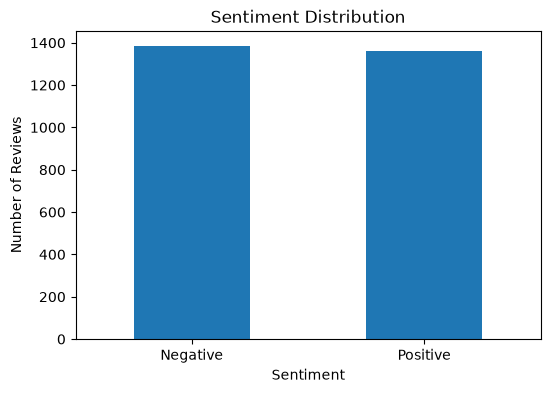

In [12]:
print(df['sentiment'].value_counts())

df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stop-word removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    # Join tokens back into text
    return ' '.join(tokens)

In [14]:
sample_text = df['review'].iloc[0]

print("Original Text:")
print(sample_text)

print("\nProcessed Text:")
print(preprocess_text(sample_text))

Original Text:
So there is no way for me to plug it in here in the US unless I go by a converter.

Processed Text:
way plug u unless go converter


In [15]:
df['processed_review'] = df['review'].apply(preprocess_text)

df[['review', 'processed_review', 'sentiment']].head(10)

,review,processed_review,sentiment
0,So there is no way for me to plug it in here i...,way plug u unless go converter,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great jawbone,1
3,Tied to charger for conversations lasting more...,tied charger conversation lasting minutesmajor...,0
4,The mic is great.,mic great,1
5,I have to jiggle the plug to get it to line up...,jiggle plug get line right get decent volume,0
6,If you have several dozen or several hundred c...,several dozen several hundred contact imagine ...,0
7,If you are Razr owner...you must have this!,razr owneryou must,1
8,"Needless to say, I wasted my money.",needless say wasted money,0
9,What a waste of money and time!.,waste money time,0


In [16]:
df.head()

,review,sentiment,processed_review
0,So there is no way for me to plug it in here i...,0,way plug u unless go converter
1,"Good case, Excellent value.",1,good case excellent value
2,Great for the jawbone.,1,great jawbone
3,Tied to charger for conversations lasting more...,0,tied charger conversation lasting minutesmajor...
4,The mic is great.,1,mic great


In [17]:
X = df['processed_review']
y = df['sentiment']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2748,)
y shape: (2748,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2198
Testing samples: 550


In [19]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2198, 4136)
Testing TF-IDF shape: (550, 4136)


In [22]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of features: 4136

First 20 features:
['aailiyah' 'abandoned' 'abhor' 'ability' 'able' 'abound' 'abovepretty'
 'abroad' 'absolute' 'absolutel' 'absolutely' 'absolutley' 'abstruse'
 'abysmal' 'academy' 'accept' 'acceptable' 'access' 'accessable'
 'accessible']


In [23]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [24]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed.")
print(y_pred[:20])

Predictions completed.
[0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]


In [25]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.45%


In [26]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.84      0.78      0.81       273
    Positive       0.80      0.85      0.82       277

    accuracy                           0.81       550
   macro avg       0.82      0.81      0.81       550
weighted avg       0.82      0.81      0.81       550



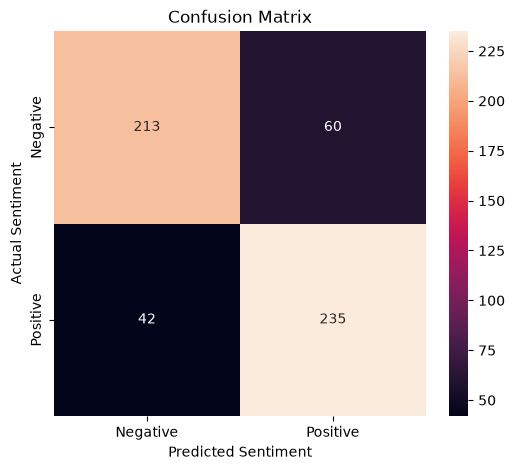

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

In [28]:
new_reviews = [
    "This product is excellent and I absolutely love it.",
    "The product is terrible and I am very disappointed.",
    "Amazing quality and great value for money.",
    "Worst experience ever. I would not recommend this product."
]

processed_reviews = [
    preprocess_text(review)
    for review in new_reviews
]

new_reviews_tfidf = tfidf.transform(processed_reviews)

predictions = model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 60)

Review: This product is excellent and I absolutely love it.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The product is terrible and I am very disappointed.
Predicted Sentiment: Negative
------------------------------------------------------------
Review: Amazing quality and great value for money.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: Worst experience ever. I would not recommend this product.
Predicted Sentiment: Negative
------------------------------------------------------------
